# Customer Segmentation com Machine Learning

Este projeto utiliza técnicas de Machine Learning não supervisionado para segmentar clientes de um e-commerce brasileiro com base em comportamento de compra.

O objetivo é identificar diferentes perfis de clientes para apoiar estratégias de marketing, retenção e personalização.

O dataset utilizado foi o Brazilian E-Commerce Public Dataset by Olist.

## Bibliotecas utilizadas

Neste projeto foram utilizadas bibliotecas para manipulação de dados, visualização, pré-processamento e modelagem não supervisionada.

- Pandas e NumPy para tratamento e manipulação dos dados
- Matplotlib e Seaborn para visualização
- Scikit-learn para padronização dos dados, KMeans, Silhouette Score e PCA

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

## 1. Carregamento dos dados

In [3]:
customers = pd.read_csv(r"data/olist_customers_dataset.csv")
orders = pd.read_csv(r"data/olist_orders_dataset.csv")
order_items = pd.read_csv(r"data/olist_order_items_dataset.csv")
payments = pd.read_csv(r"data/olist_order_payments_dataset.csv")

In [4]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)


## 2. Entendimento inicial das tabelas

 Análise das dimensões, primeiras linhas, valores nulos e duplicidades das tabelas utilizadas.

In [5]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [9]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [10]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [11]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [12]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [13]:
customers.duplicated().sum()

np.int64(0)

In [14]:
orders.duplicated().sum()

np.int64(0)

In [15]:
order_items.duplicated().sum()

np.int64(0)

In [16]:
payments.duplicated().sum()

np.int64(0)

## 3. Integração das bases

Tabelas clientes, pedidos, itens e pagamentos integradas por meio das chaves `customer_id` e `order_id`, criando uma base transacional consolidada.

In [17]:
df = customers.merge(
    orders,
    on = 'customer_id', 
    how = 'inner'
)

In [18]:
df = df.merge(
    order_items,
    on = 'order_id', 
    how = 'inner'
)

In [19]:
df = df.merge(
    payments,
    on = 'order_id',
    how = 'inner'
)

In [20]:
df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value'],
      dtype='str')

In [21]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

In [22]:
df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,1,credit_card,2,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,1,credit_card,8,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,1,credit_card,7,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,1,credit_card,1,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,1,credit_card,8,252.25


## 4. Feature Engineering

Dados transacionais agregados no nível do cliente. Cada linha passa a representar um cliente único, com métricas de comportamento de compra.

In [23]:
reference_date = df["order_purchase_timestamp"].max()

customer_df = df.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (reference_date - x.max()).days,
    "order_id": "nunique",
    "payment_value": "sum",
    "price": "mean",
    "freight_value": "mean",
    "payment_installments": "mean"
})

In [24]:
customer_df.columns = [
    "recency_days",
    "order_count",
    "total_spent",
    "avg_product_prices",
    "avg_freight",
    "avg_installments"
]

In [25]:
customer_df["avg_ticket"] = (
    customer_df["total_spent"] / customer_df["order_count"]
)

In [26]:
customer_df.head()


,recency_days,order_count,total_spent,avg_product_prices,avg_freight,avg_installments,avg_ticket
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,115,1,141.90,129.90,12.00,8.0,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,27.19,18.90,8.29,1.0,27.19
0000f46a3911fa3c0805444483337064,541,1,86.22,69.00,17.22,8.0,86.22
0000f6ccb0745a6a4b88665a16c9f078,325,1,43.62,25.99,17.63,4.0,43.62
0004aac84e0df4da2b147fca70cf8255,292,1,196.89,180.00,16.89,6.0,196.89


## 5. Análise Exploratória dos Dados (EDA)

Análise das distribuições das variáveis criadas para entender o comportamento dos clientes, identificar assimetrias e detectar possíveis outliers.

In [27]:
customer_df.shape

(95419, 7)

### Estatísticas descritivas


In [28]:
customer_df.describe()

,recency_days,order_count,total_spent,avg_product_prices,avg_freight,avg_installments,avg_ticket
count,95419.000000,95419.000000,95419.000000,95419.000000,95419.000000,95419.000000,95419.000000
mean,242.595406,1.034018,212.831142,126.519964,20.226946,2.903669,205.462038
std,153.153422,0.211235,641.763082,191.747240,15.821267,2.678526,619.347716
min,0.000000,1.000000,9.590000,0.850000,0.000000,0.000000,9.590000
25%,118.000000,1.000000,63.910000,42.900000,13.370000,1.000000,63.130000
50%,223.000000,1.000000,113.150000,79.080000,16.400000,2.000000,110.630000
75%,352.000000,1.000000,202.545000,139.900000,21.220000,4.000000,196.010000
max,728.000000,16.000000,109312.640000,6735.000000,409.680000,24.000000,109312.640000


### Distribuição das variáveis

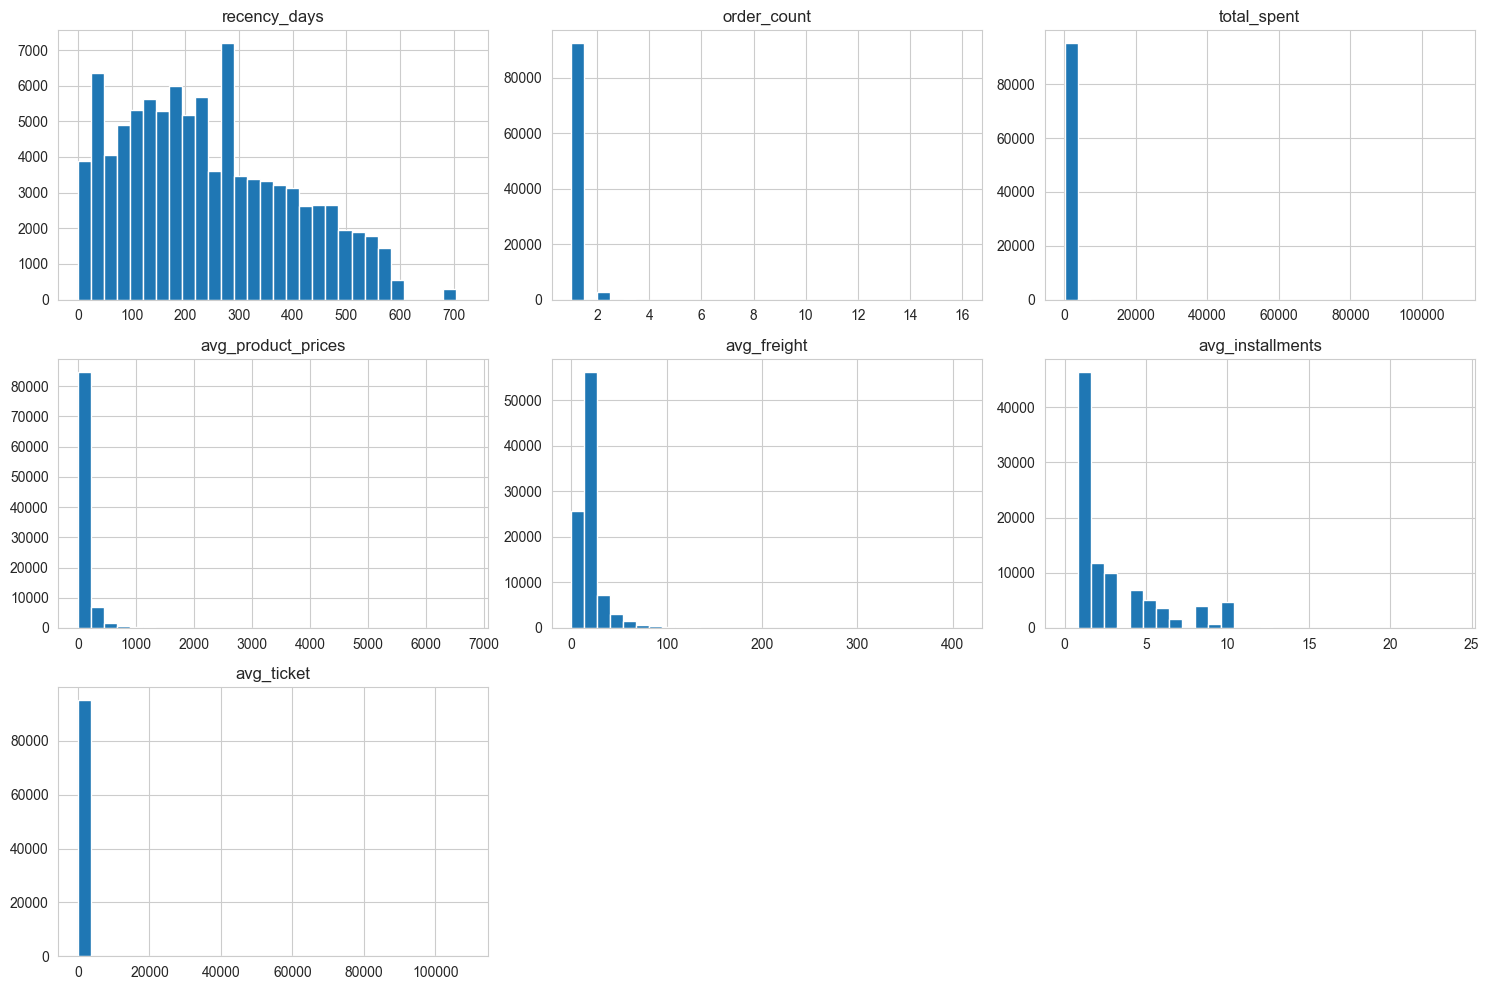

In [29]:
customer_df.hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

### Identificação de outliers

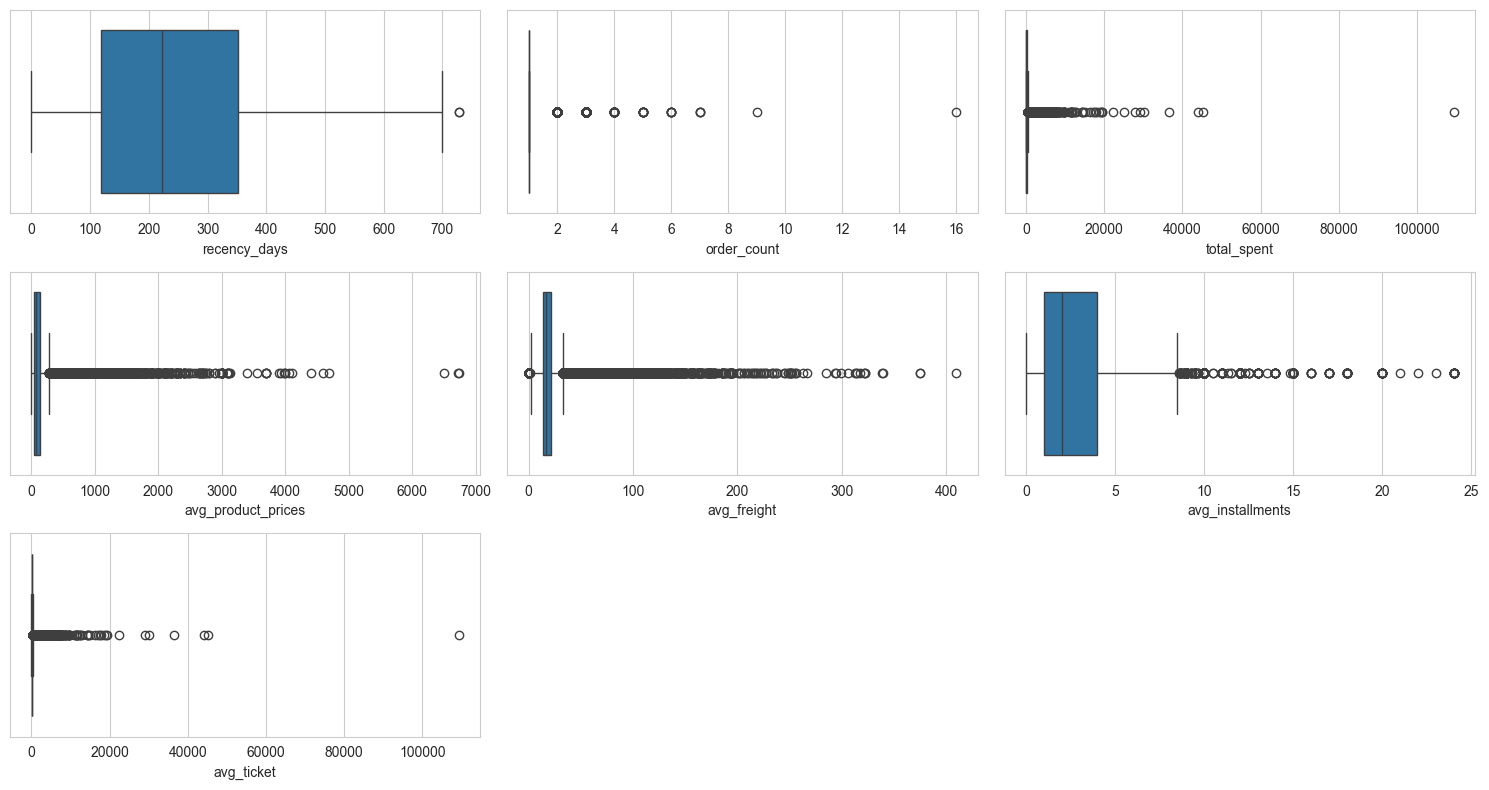

In [30]:
plt.figure(figsize=(15,8))

for i, col in enumerate(customer_df.columns, 1):
    plt.subplot(3,3,i)
    sns.boxplot(x=customer_df[col])
    
plt.tight_layout()
plt.show()

## 6. Transformação Logarítmica

Assimetria e presença de outliers em algumas variáveis.
Para reduzir o impacto desses valores extremos e melhorar a performance do clustering, foi aplicada transformação logarítmica.

In [31]:
customer_log = customer_df.copy()

In [32]:
log_columns = [
     "order_count",
     "total_spent",
     "avg_ticket",
     "avg_product_prices",
     "avg_freight"
 ]
 
for col in log_columns:
    customer_log[col] = np.log1p(customer_log[col])

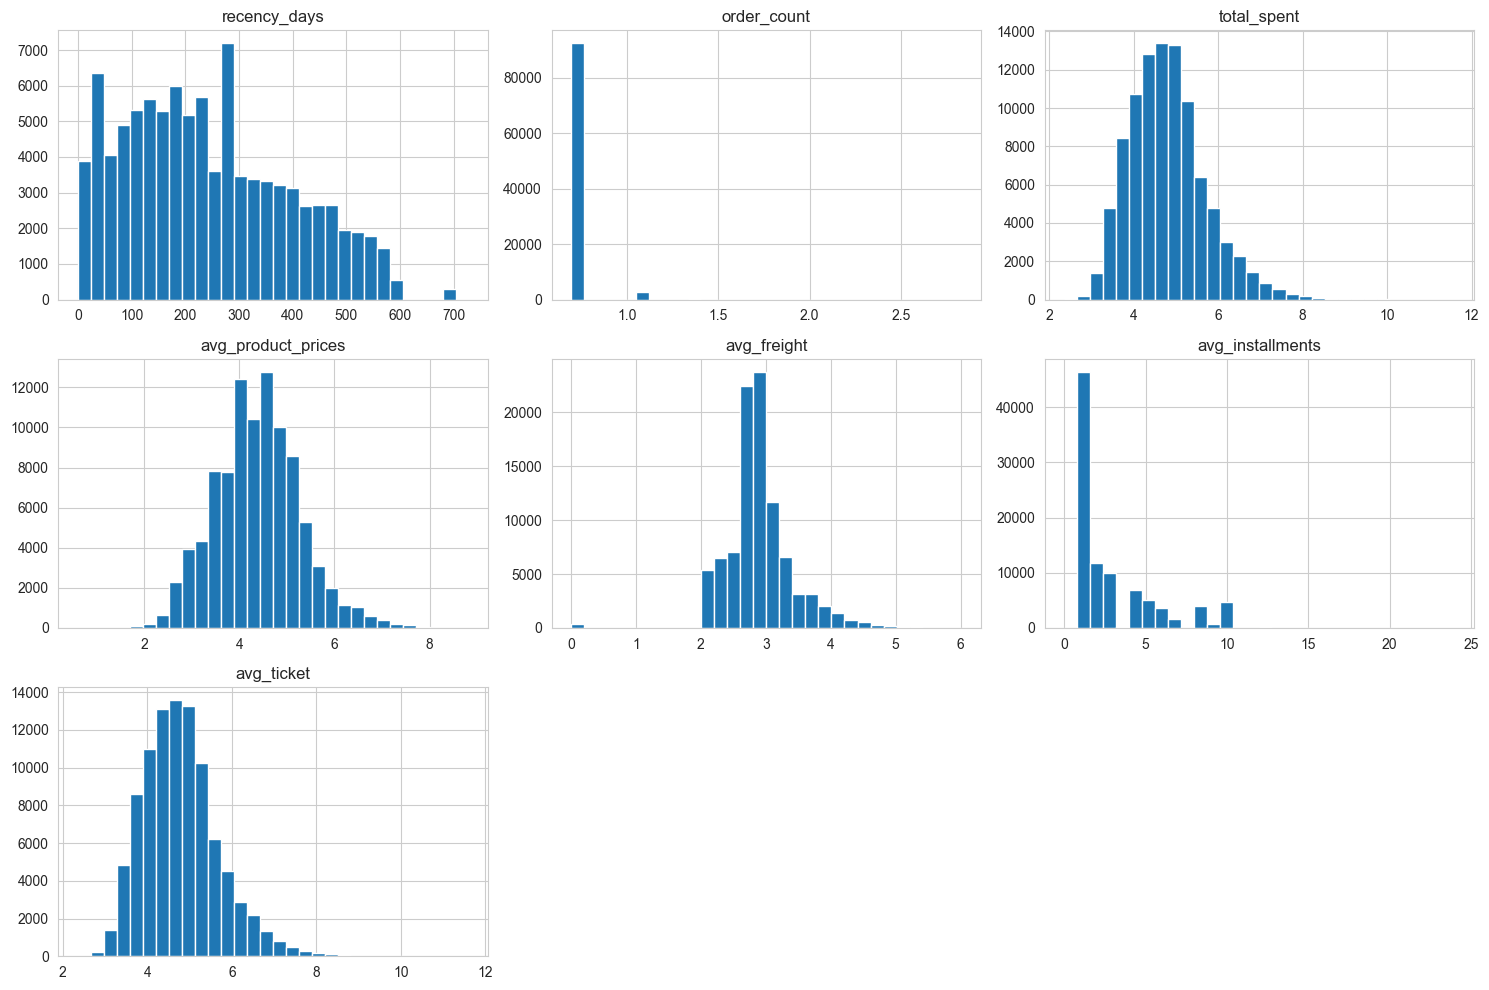

In [33]:
customer_log.hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

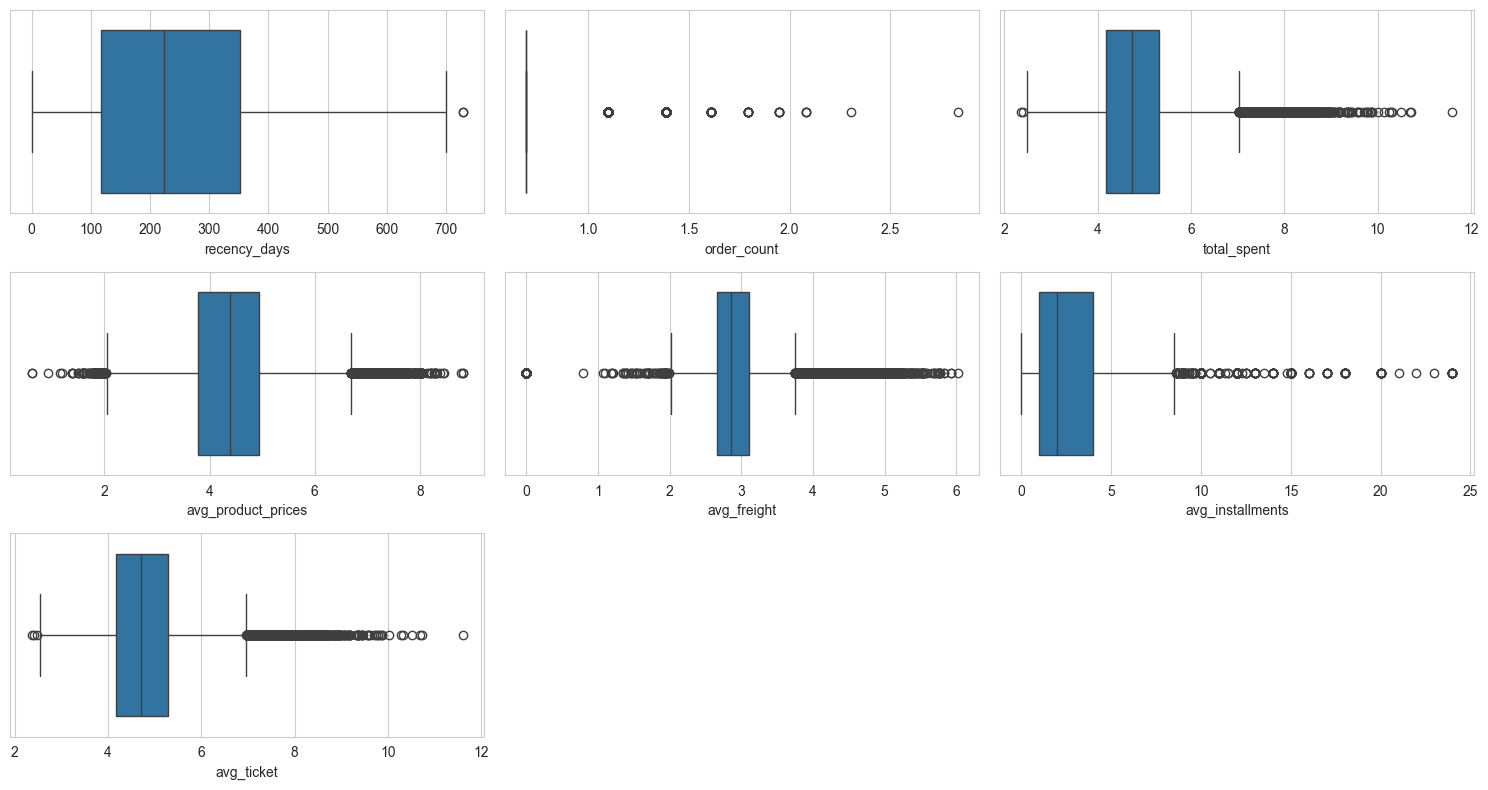

In [34]:
plt.figure(figsize=(15,8))

for i, col in enumerate(customer_log.columns, 1):
    plt.subplot(3,3,i)
    sns.boxplot(x=customer_log[col])
    
plt.tight_layout()
plt.show()

## 7. Padronização dos Dados

In [35]:
scaler = StandardScaler()

In [36]:
scaled_data = scaler.fit_transform(customer_log)

In [37]:
scaled_data[:5]


array([[-0.83312584, -0.1717427 ,  0.16276135,  0.5406674 , -0.68690242,
         1.90267237,  0.18975014],
       [-0.81353754, -0.1717427 , -1.62436942, -1.54379362, -1.35490312,
        -0.71071866, -1.621151  ],
       [ 1.94841326, -0.1717427 , -0.38081858, -0.15197718, -0.01580094,
         1.90267237, -0.36105988],
       [ 0.5380554 , -0.1717427 , -1.11877043, -1.20657012,  0.02843935,
         0.40930607, -1.10882711],
       [ 0.32258406, -0.1717427 ,  0.5212122 ,  0.89926614, -0.0521382 ,
         1.15598922,  0.55296868]])

## 8. Escolha do Número de Clusters

Foram utilizados os métodos Elbow Method e Silhouette Score para identificar o número ideal de clusters para o modelo.

### Elbow Method

In [38]:
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(scaled_data)
    
    inertia.append(kmeans.inertia_)

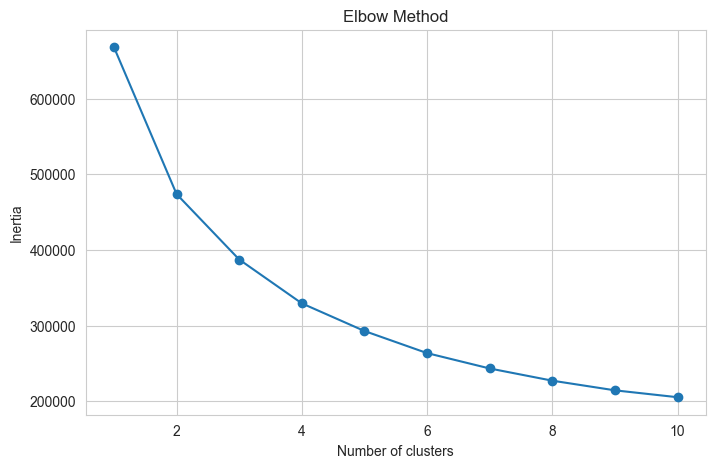

In [39]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

### Silhouette Score

In [40]:
silhouette_scores = []

for k in range(2,11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    labels = kmeans.fit_predict(scaled_data)
    
    score = silhouette_score(
        scaled_data,
        labels
    )
    
    silhouette_scores.append(score)

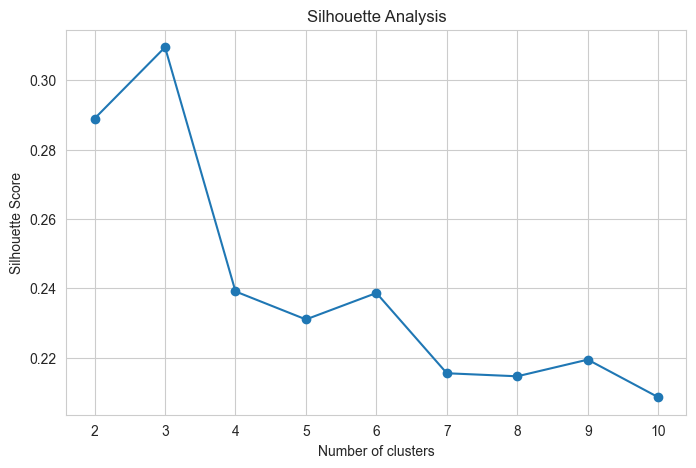

In [41]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.show()

O Elbow Method indicou redução significativa da inertia até aproximadamente k=3.

Além disso, o maior valor do Silhouette Score também foi obtido com k=3, indicando melhor separação entre os clusters.

Dessa forma, foi escolhido k=3 para o modelo final.

## 9. Treinamento do Modelo KMeans

In [42]:
kmeans = KMeans(
    n_clusters = 3,
    random_state=42
)

### Aplicação do KMeans

Agrupar clientes com comportamentos semelhantes, considerando métricas de frequência, gasto, ticket médio e recência.

In [43]:
customer_log["cluster"] = kmeans.fit_predict(scaled_data)

In [44]:
customer_log.head()

,recency_days,order_count,total_spent,avg_product_prices,avg_freight,avg_installments,avg_ticket,cluster
customer_unique_id,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,115,0.693147,4.962145,4.874434,2.564949,8.0,4.962145,1
0000b849f77a49e4a4ce2b2a4ca5be3f,118,0.693147,3.338967,2.990720,2.228939,1.0,3.338967,0
0000f46a3911fa3c0805444483337064,541,0.693147,4.468434,4.248495,2.902520,8.0,4.468434,0
0000f6ccb0745a6a4b88665a16c9f078,325,0.693147,3.798182,3.295466,2.924773,4.0,3.798182,0
0004aac84e0df4da2b147fca70cf8255,292,0.693147,5.287711,5.198497,2.884242,6.0,5.287711,1


### Distribuição dos clientes por cluster

A análise abaixo mostra a quantidade de clientes atribuídos a cada grupo identificado pelo modelo.

In [45]:
customer_log["cluster"].value_counts()

cluster
0    54385
1    38121
2     2913
Name: count, dtype: int64

In [46]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [47]:
cluster_profile = customer_log.groupby("cluster").mean()

In [48]:
cluster_profile

,recency_days,order_count,total_spent,avg_product_prices,avg_freight,avg_installments,avg_ticket
cluster,,,,,,,
0,244.074469,0.693147,4.222057,3.857500,2.713682,1.869620,4.222057
1,241.814354,0.693147,5.597275,5.140264,3.191883,4.347819,5.597275
2,225.202884,1.128274,5.625434,4.376917,2.901683,3.310214,4.896587


## 10. Visualização dos Clusters com PCA

Como os dados possuem múltiplas dimensões, foi utilizada a técnica PCA (Principal Component Analysis) para reduzir as variáveis para duas dimensões e permitir visualização gráfica dos clusters.

In [49]:
pca = PCA(n_components=2)

In [50]:
pca_data = pca.fit_transform(scaled_data)

In [51]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

In [52]:
pca_df["cluster"] = customer_log["cluster"].values

### Visualização bidimensional dos clusters

Cada ponto representa um cliente, enquanto as cores representam os grupos identificados pelo modelo KMeans.

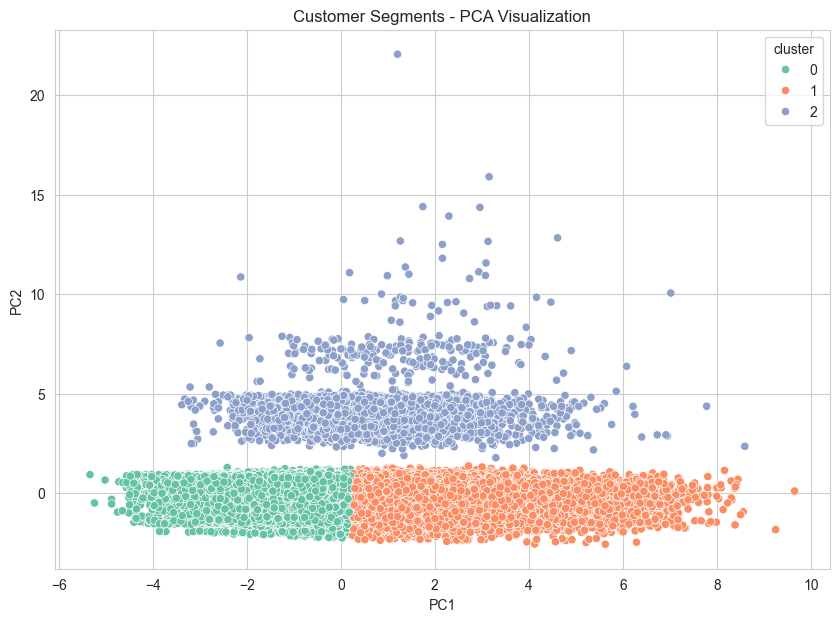

In [53]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2"
)

plt.title("Customer Segments - PCA Visualization")

plt.show()

Os clusters apresentaram separação visual consistente, indicando que o modelo conseguiu identificar padrões distintos de comportamento entre os clientes.

Foi possível observar grupos relacionados a:
- clientes econômicos
- clientes premium
- clientes recorrentes

## 11. Perfil dos Clusters

Análise das médias das variáveis de cada cluster para interpretação dos perfis de clientes encontrados.

In [54]:
cluster_profile = customer_df.copy()

In [55]:
cluster_profile["cluster"] = customer_log["cluster"]

In [56]:
cluster_summary = cluster_profile.groupby("cluster").mean()

In [57]:
cluster_summary

,recency_days,order_count,total_spent,avg_product_prices,avg_freight,avg_installments,avg_ticket
cluster,,,,,,,
0,244.074469,1.000000,75.968343,54.849263,15.086849,1.869620,75.968343
1,241.814354,1.000000,389.667420,230.264221,27.654196,4.347819,389.667420
2,225.202884,2.114315,453.856739,106.944357,18.994524,3.310214,212.472434


### Cluster 0 — Clientes Econômicos

Clientes com baixo gasto total, baixo ticket médio e poucas compras. Representam consumidores ocasionais e mais sensíveis a preço.

---

### Cluster 1 — Clientes Premium

Clientes com maior ticket médio e produtos mais caros. Apesar de menor recorrência, possuem alto valor financeiro por compra.

---

### Cluster 2 — Clientes Fiéis

Clientes com maior frequência de compras, maior gasto acumulado e comportamento mais recorrente, representando o grupo com maior potencial de retenção.

# 12. Conclusão

O projeto aplicou técnicas de Machine Learning não supervisionado para segmentação de clientes de um e-commerce brasileiro utilizando KMeans Clustering.

Através de etapas de limpeza, transformação, padronização e análise exploratória, foi possível identificar diferentes perfis de clientes com comportamentos distintos de compra.

Os clusters encontrados permitiram identificar:
- clientes econômicos
- clientes premium
- clientes fiéis

Esses insights podem auxiliar estratégias de marketing personalizado, retenção de clientes, campanhas promocionais e aumento do valor de vida do cliente (Customer Lifetime Value).

Além disso, o uso de PCA permitiu visualizar de forma clara a separação entre os grupos identificados pelo modelo.